# Deep Dive Analysis: Portfolio Composition 2025 (Out-of-Sample)

Notebook ini difokuskan untuk membedah komposisi aset strategi **Cluster** pada periode **Out-of-Sample (Januari 2025 - Februari 2025)**.

Tujuannya adalah untuk melihat:
1. Aset apa saja yang dipilih sistem saat kondisi pasar terbaru.
2. Apakah ada pergeseran dominasi aset dibanding tahun 2024.
3. Visualisasi heatmap kepemilikan aset secara kronologis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
import networkx as nx
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)

print("✓ Libraries loaded!")

✓ Libraries loaded!


## 1. Load Data & Prepare Model
(Menggunakan data s/d 2025, model dilatih s/d 2024)

In [2]:
# Load data
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

# Features for AI
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

# Train model (up to 2024)
X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Probabilities for all period
X_all = features.dropna()
all_probs = pd.Series(xgb_model.predict_proba(X_all)[:, 1], index=X_all.index)
all_probs = all_probs.reindex(returns.index, method='ffill').fillna(method='bfill')

print("✓ Setup complete.")

✓ Setup complete.


## 2. Global Strategy Helper Functions

In [3]:
def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    num_assets = len(mu)
    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    res = minimize(objective, [1./num_assets]*num_assets, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def get_assets_graph_cluster(returns_window, corr_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) < corr_threshold: G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def run_simulation(test_dates, returns, ai_probs, threshold, market_idx, selection_func, override_ma=200, fee=0.0025):
    val = 100.0
    history = [val]; dates = [test_dates[0]]
    current_weights = {}; allocation_history = {}
    risk_status = False; days_since_rebal = 999
    market_ma = market_idx.rolling(window=override_ma).mean() if override_ma else None

    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        prev_risk_status = risk_status
        buffer = 0.05
        if not risk_status and prob > (threshold + buffer): ai_signal = True
        elif risk_status and prob < (threshold - buffer): ai_signal = False
        else: ai_signal = risk_status
        
        final_signal = ai_signal
        if market_ma is not None:
            try:
                if (market_idx.loc[date] > market_ma.loc[date]): final_signal = True
            except: pass
            
        risk_status = final_signal
        regime_changed = (risk_status != prev_risk_status)
        target_weights = current_weights.copy()
        
        if not risk_status:
            target_weights = {'CASH': 1.0}
            days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= 20:
                try:
                    loc_idx = returns.index.get_loc(date)
                    window = returns.iloc[max(0, loc_idx-60):loc_idx]
                    selected = selection_func(window)
                    if selected: 
                        target_weights = optimize_markowitz(window[selected])
                        days_since_rebal = 0
                except: pass
        
        days_since_rebal += 1
        turnover = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in set(target_weights)|set(current_weights))
        val -= val * turnover * fee
        
        next_date = test_dates[i+1]
        day_ret = 0; new_drifted = {}
        if 'CASH' in target_weights: 
            new_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                r = returns.loc[next_date, asset] if next_date in returns.index else 0
                day_ret += w * r
                new_drifted[asset] = w * (1 + r)
        
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date)
        current_weights = {k: v/sum(new_drifted.values()) for k, v in new_drifted.items()} if sum(new_drifted.values())>0 else new_drifted
        allocation_history[date] = target_weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates), allocation_history

## 3. Jalankan Simulasi untuk Tahun 2025

In [4]:
test_dates_2025 = returns.loc[returns.index.year == 2025].index
opt_t = 0.52 # Berdasarkan optimasi di notebook sebelumnya

val_2025, alloc_2025 = run_simulation(test_dates_2025, returns, all_probs, opt_t, market_index, get_assets_graph_cluster)

print(f"Simulasi 2025 Selesai. Total Return: {((val_2025['Portfolio_Value'].iloc[-1]/100)-1)*100:.2f}%")

Simulasi 2025 Selesai. Total Return: -24.75%


## 4. Visualisasi Komposisi Portofolio 2025

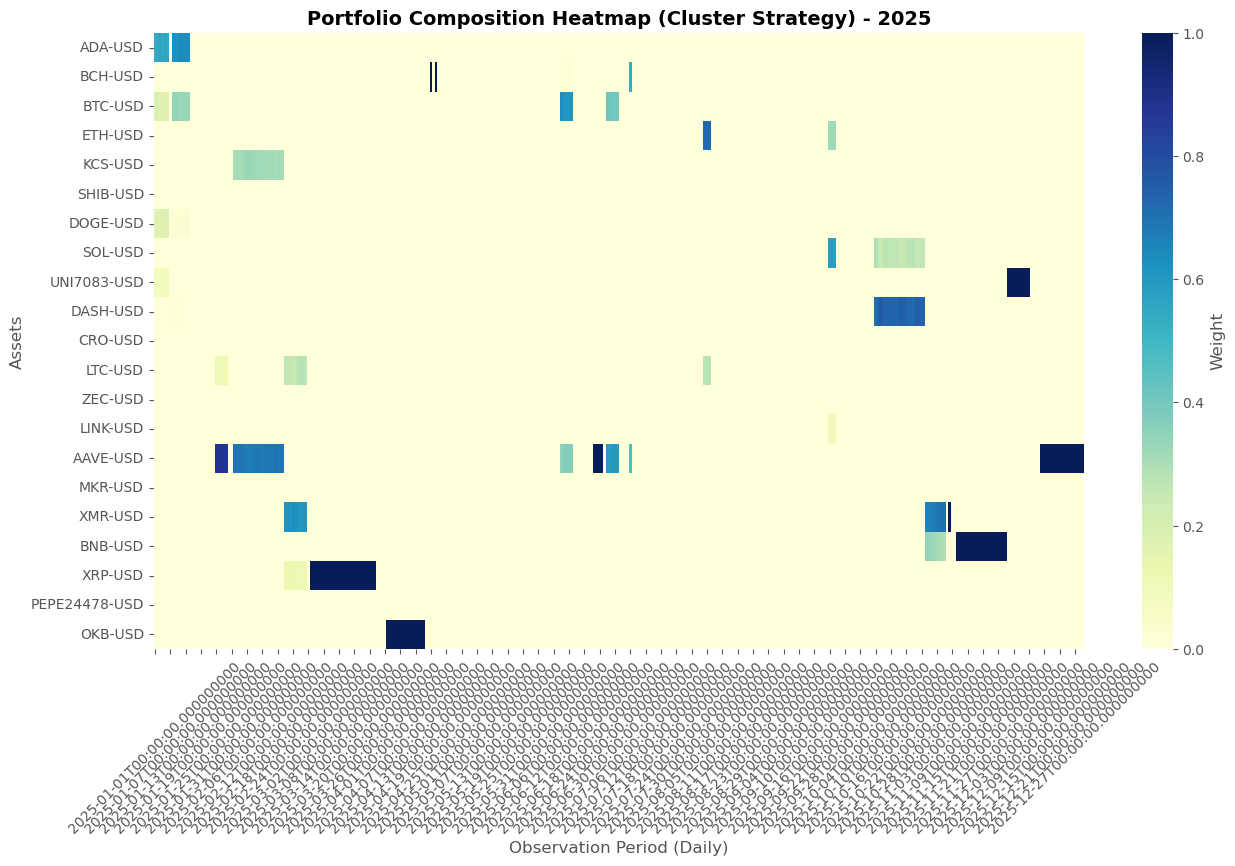

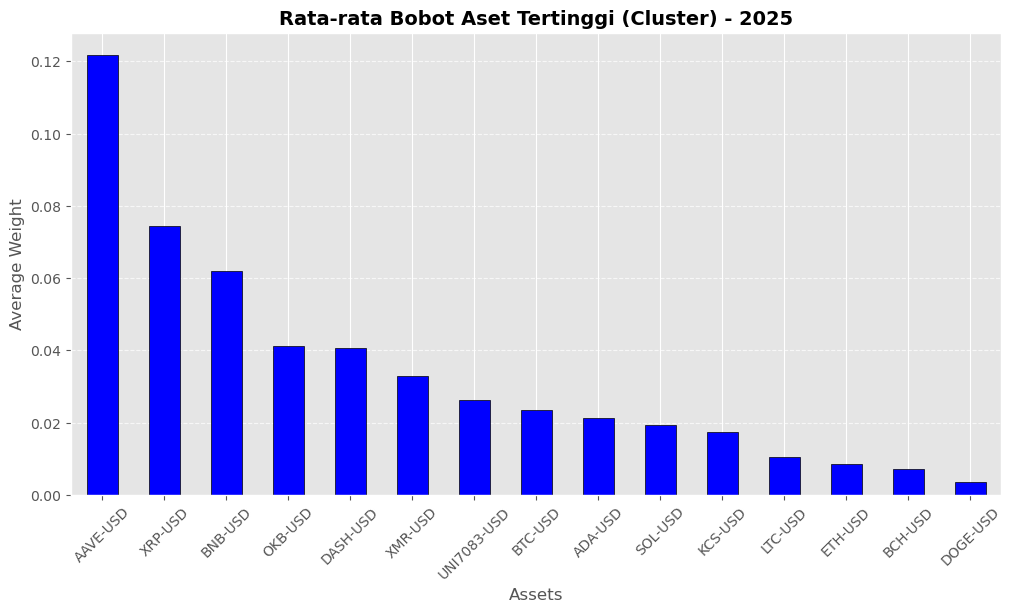

In [5]:
# Convert allocation history to DataFrame
df_alloc = pd.DataFrame(alloc_2025).T.fillna(0)
active_assets = [a for a in df_alloc.columns if a != 'CASH' and df_alloc[a].sum() > 0]

if len(active_assets) > 0:
    # 1. Portfolio Composition Heatmap
    plt.figure(figsize=(15, 8))
    sns.heatmap(df_alloc[active_assets].T, cmap="YlGnBu", cbar_kws={'label': 'Weight'})
    plt.title("Portfolio Composition Heatmap (Cluster Strategy) - 2025", fontsize=14, fontweight='bold')
    plt.xlabel("Observation Period (Daily)", fontsize=12)
    plt.ylabel("Assets", fontsize=12)
    plt.xticks(rotation=45)
    plt.savefig('cluster_composition_heatmap_2025.png', bbox_inches='tight')
    plt.show()

    # 2. Average Asset Weight Bar Chart
    top_assets = df_alloc[active_assets].mean().sort_values(ascending=False).head(15)
    plt.figure(figsize=(12, 6))
    top_assets.plot(kind='bar', color='blue', edgecolor='black')
    plt.title("Rata-rata Bobot Aset Tertinggi (Cluster) - 2025", fontsize=14, fontweight='bold')
    plt.ylabel("Average Weight", fontsize=12)
    plt.xlabel("Assets", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig('cluster_asset_weights_2025.png', bbox_inches='tight')
    plt.show()
else:
    print("Strategi sedang dalam posisi CASH penuh di periode ini berdasarkan sinyal AI.")

## 5. Summary Findings (2025)

Gunakan hasil grafik di atas untuk menjawab pertanyaan tesis:
- Apakah koin yang dipilih tetap berkerumun di sektor yang sama?
- Bagaimana ketahanan strategi ini saat menghadapi volatilitas awal tahun 2025?
- Apakah diversifikasi internal dalam cluster tetap terjaga?